# Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import scipy.optimize
import scipy.special
import time

## Shooting method for waves on a string

Found omega = 1.00001 pi, n = 0
Found omega = 2.00002 pi, n = 1
Found omega = 3.00003 pi, n = 2
Found omega = 4.00004 pi, n = 3
Found omega = 5.00005 pi, n = 4
Found omega = 6.00006 pi, n = 5


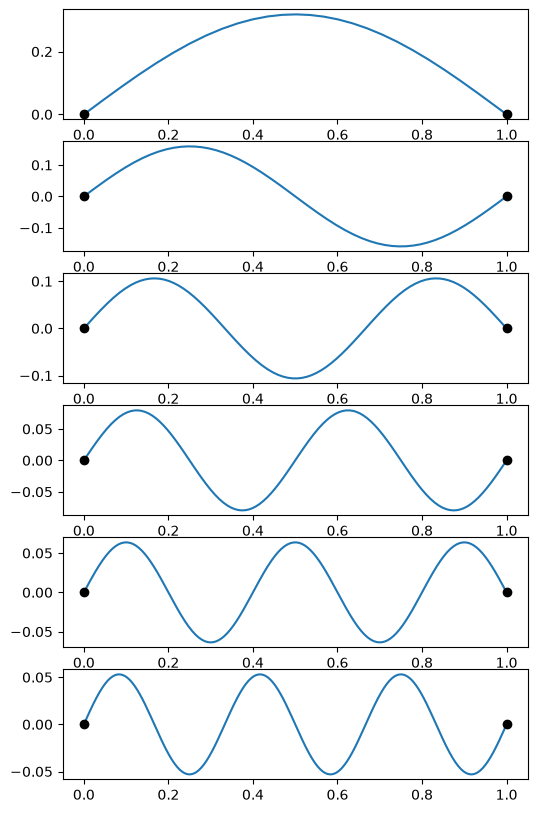

In [2]:
# First do the constant density string to check with the known frequencies
# and eigenfunctions

def derivs(x, y, omega):
    f, g = y
    dfdx = g
    rho = 1
    dgdx = - omega**2 * rho * f
    return dfdx, dgdx

def do_integration(omega):
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    return result.y[0,-1]

fig = plt.figure(figsize = (6,10))

# We'll take advantage of the known frequencies for this case to define the search windows
oms = np.pi * np.array((1,2,3,4,5,6))
num = len(oms)

for i, om in enumerate(oms):
    # search within 10% of the analytic frequency
    omega = scipy.optimize.brentq(do_integration, 0.9*om, 1.1*om)
    
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    x = result.t
    f = result.y[0]

    # find the number of zero crossings (not including the endpoints)
    n = ((f[1:-1] * f[:-2]) < 0).sum()
    print("Found omega = %lg pi, n = %d" % (omega/np.pi,n))

    plt.subplot(num,1,1+i)
    plt.plot(x, f)
    plt.plot((0,1),(0,0), 'ko')

plt.show()

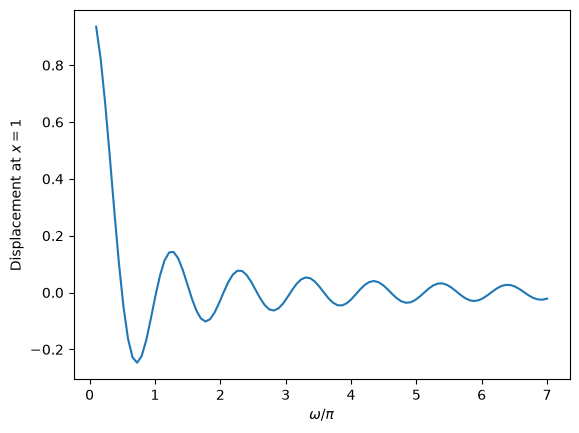

Frequency guesses= [0.44848485 1.00606061 1.49393939 1.98181818 2.53939394 3.02727273
 3.58484848 4.07272727 4.56060606 5.11818182 5.60606061 6.09393939
 6.65151515]
Found omega = 0.493438 pi, n = 0
Found omega = 1.01755 pi, n = 1
Found omega = 1.53483 pi, n = 2
Found omega = 2.0489 pi, n = 3
Found omega = 2.56151 pi, n = 4
Found omega = 3.0735 pi, n = 5
Found omega = 3.58524 pi, n = 6
Found omega = 4.0969 pi, n = 7
Found omega = 4.60855 pi, n = 8
Found omega = 5.12021 pi, n = 9
Found omega = 5.63189 pi, n = 10
Found omega = 6.14359 pi, n = 11
Found omega = 6.65531 pi, n = 12


<Figure size 640x480 with 0 Axes>

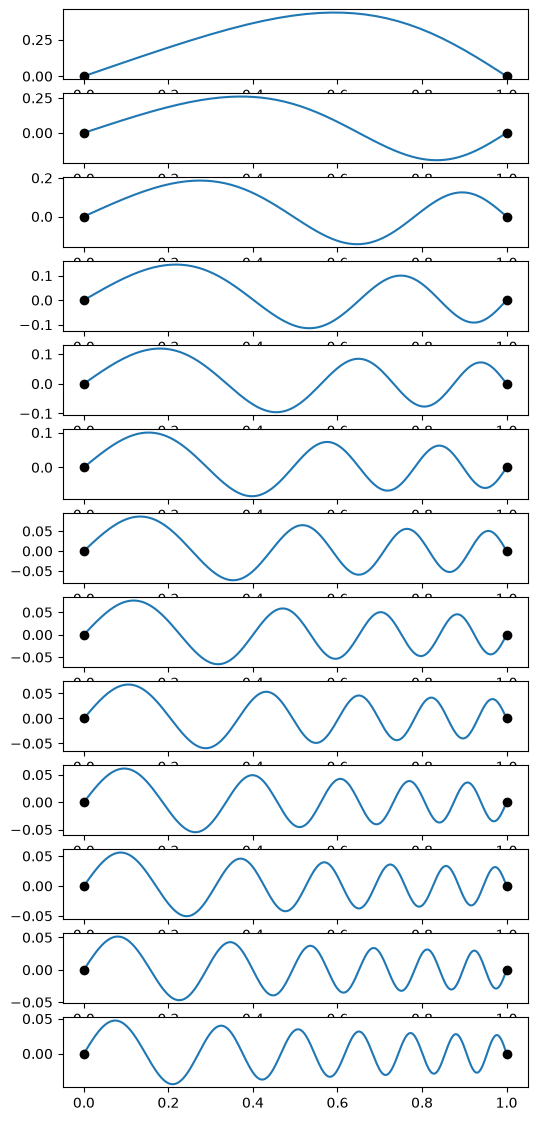

In [3]:
# Now do an x-dependent density
def rho(x):
    rho = 1.0 + 10*x**2
    #rho = np.ones_like(x)
    return rho

def derivs(x, y, omega):
    f, g = y
    dfdx = g
    dgdx = - omega**2 * rho(x) * f
    return dfdx, dgdx

def do_integration(omega):
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    return result.y[0,-1]

# Evaluate the displacement at x=1 on a grid of omega
oms = np.pi * np.linspace(0.1,7,100)
result = np.array([do_integration(om) for om in oms]) 
plt.plot(oms/np.pi, result)
plt.xlabel(r'$\omega/\pi$')
plt.ylabel(r'Displacement at $x=1$')
plt.show()
# identify the zero-crossings as initial guesses for mode frequencies
inds = np.where(np.diff(np.sign(result)))[0]
print('Frequency guesses=', oms[inds]/np.pi)

plt.clf()
num = len(inds)
fig = plt.figure(figsize = (6,14))

for i, ind in enumerate(inds):
    omega = scipy.optimize.brentq(do_integration, oms[ind], oms[ind+1])

    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    x = result.t
    f = result.y[0]

    # find the number of zero crossings (not including the endpoints)
    n = ((f[1:-1] * f[:-2]) < 0).sum()
    print("Found omega = %lg pi, n = %d" % (omega/np.pi,n))

    plt.subplot(num,1,1+i)
    plt.plot(x, f)
    plt.plot((0,1),(0,0), 'ko')

plt.show()

# Store the last eigenfunction we found to compare later with the relaxation result
x_s = x
f_s = f
om_s = omega


## Relaxation method for waves on a string

In [4]:
def calculate_F(f, x, omega):
    F = np.zeros(ngrid)
    dx = x[1]-x[0]  # assume constant spacing    
    F[1:-1] = f[2:] - (2 - dx**2 * omega**2 * rho(x[1:-1]))*f[1:-1] + f[:-2]
    F[0] = f[0]  #bc
    F[-1] = f[-1] #bc
    return F

# Calculate the Jacobian in banded form
def calculate_J_banded(f, x, omega):
    dx = x[1]-x[0]  # assume constant spacing

    a = np.ones_like(x)
    a[0] = 0  # upper diagonal so don't need this
    a[1] = 0  # bc

    b = - (2 - dx**2 * omega**2 * rho(x))
    b[0] = 1  #bc
    b[-1] = 1 #bc
    
    c = np.ones_like(x)
    c[-2] = 0 # bc
    c[-1] = 0 # lower diagonal so don't need this
    
    return np.vstack((a,b,c))

F=1; Solve took 0.000614643 seconds


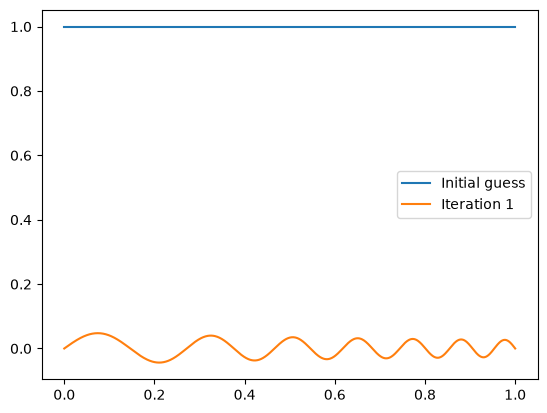

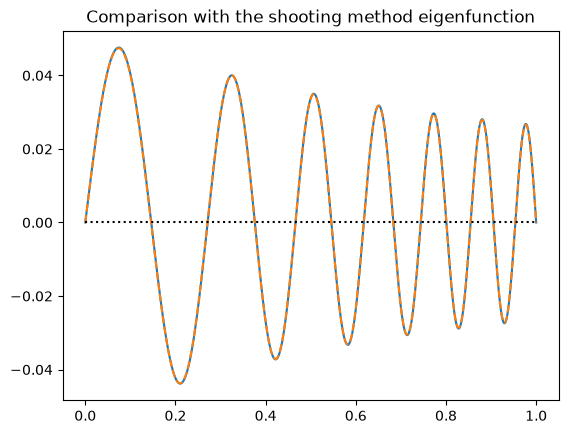

In [5]:
# Use the frequency from the shooting method:
omega = om_s
ngrid = 1000
x = np.linspace(0,1,ngrid)
dx = x[1]-x[0]

# Initial guess
f = np.ones_like(x)
plt.plot(x, f, label='Initial guess')

niter = 1
for m in range(niter):

    t0 = time.time()

    F = calculate_F(f, x, omega)
    J = calculate_J_banded(f, x, omega)
        
    df = -scipy.linalg.solve_banded((1,1), J, F)
    f = f + df

    # readjust normalization to keep df/dx=1 at x=0
    f = f * dx/ (f[1]-f[0])

    print('F=%lg; Solve took %lg seconds' % (max(abs(F)),time.time()-t0,))
    plt.plot(x, f, label='Iteration %d' % (m+1,))

plt.legend()
plt.show()

plt.clf()
plt.plot(x,f)
# compare with the analytic solution for constant density:
#plt.plot(x, np.sin(5 * np.pi * x), ":")
# compare with the shooting result:
plt.title('Comparison with the shooting method eigenfunction')
plt.plot(x_s, f_s, "--")
plt.plot((0,1),(0,0),"k:")

plt.show()

## Laplace's equation: Jacobi method

The basic idea here is that the solution diffuses in from the boundaries (the Laplacian operator is the same operator we had in the diffusion equation). Diffusion over a lengthscale $L$ takes a time $t_\mathrm{diff}\approx L^2/D$ where $D$ is the diffusion coefficient. In the Jacobi update, the "timestep" we are using corresponds to $\alpha\approx 1$ in the explicit diffusion method, i.e. $\Delta t\approx (\Delta x)^2/D$. Therefore the number of timesteps needed for the solution to diffuse in from the boundaries is
$$n_\mathrm{iter}\approx {L^2/D\over (\Delta x)^2/D} = \left({L\over \Delta x}\right)^2 = n_\mathrm{grid}^2$$ where $n_\mathrm{grid}$ is the number of grid points. In the version of the code below, the vertical dashed line is at $n_\mathrm{iter}=(n_\mathrm{grid}/2)^2$ (since we have to diffuse across half the grid roughly) and matches well with the rapid decrease of $\Delta V$ after that point.

In [6]:
def set_bcs(n):
    # Create a mask to set the boundary points
    # (following https://github.com/sievers/phys512-2022/tree/master/pdes )
    
    # create a 2D array filled with the value of r, distance from the center
    x = np.linspace(-1,1,n)
    xsqr = np.outer(x**2,np.ones(n))
    rsqr = xsqr+xsqr.T
    # this will be the size of the central circle
    R = 0.1
    
    # points in the mask that are True correspond to boundary points
    mask = np.zeros([n,n],dtype='bool')
    mask[rsqr<R**2] = True
    mask[:,0] = True
    mask[0,:] = True
    mask[-1,:] = True
    mask[:,-1] = True
    
    # bc contains the values of V in the boundary points
    bc = np.zeros([n,n])
    bc[rsqr < R**2] = 1.0

    return mask, bc

def laplace(mask, bc, niter, V, make_plot=True):
    # implements the Jacobi method to solve Laplace's equation

    # keep track of how much V changes from one iteration to the next
    deltaV = np.zeros(niter)
    
    t0 = time.time()
    for i in range(niter):
        # Jacobi update
        Vnew = V + 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + 
                       np.roll(V,1,1) + np.roll(V,-1,1) - 4*V)
        # Now reapply the boundary conditions
        Vnew[mask] = bc[mask]
        # Store how much V changed this iteration
        deltaV[i] = np.max(np.abs(Vnew-V))

        V = Vnew

        if (i+1)%1000 == 0 and make_plot:
            n = len(V[0,:])
            plt.plot(np.arange(n), V[n//2,:])

    print('n=%d : %d iterations took %lg seconds' %(len(V[0,:]), niter, time.time()-t0))

    return V, deltaV

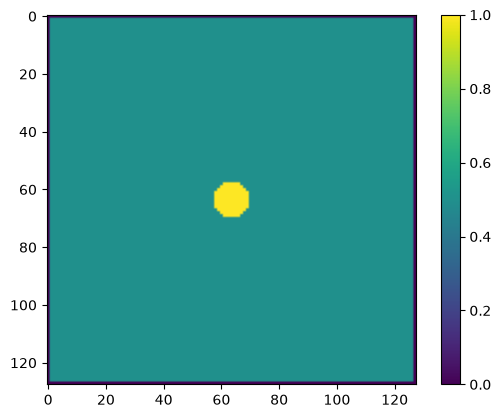

n=128 : 32768 iterations took 1.45641 seconds


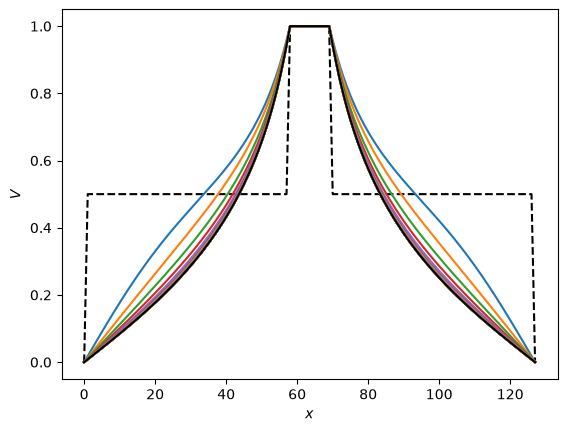

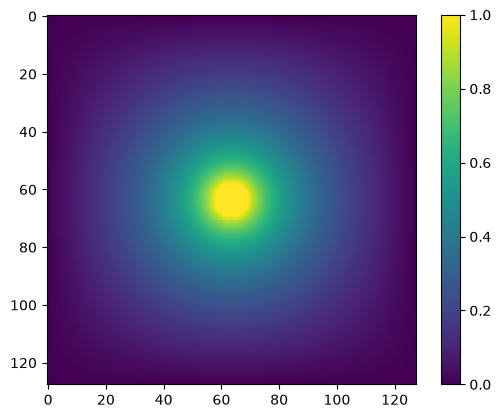

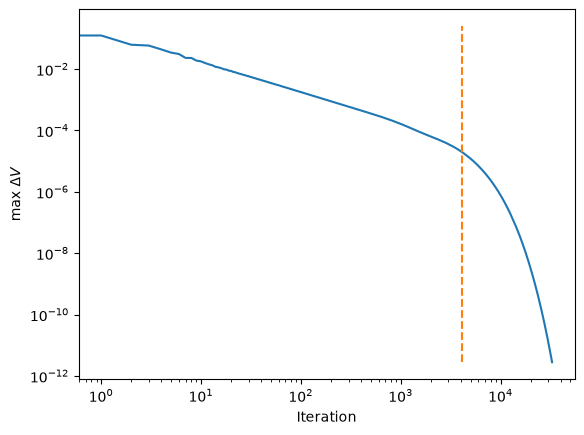

In [7]:
# Solve Laplace's equation with Jacobi method
n = 128  # number of grid points (n x n grid)
niter = 2 * n**2 # number of iterations
mask, bc = set_bcs(n)

# Initial guess for the potential 
V = np.zeros([n,n]) + 0.5
V[mask] = bc[mask]

plt.imshow(V)
plt.colorbar()
plt.show()
plt.clf()
plt.plot(np.arange(n), V[int(n/2),:], 'k--')
plt.ylabel(r'$V$')
plt.xlabel(r'$x$')

V_jacobi, deltaV_jacobi = laplace(mask, bc, niter, V)
    
plt.plot(np.arange(n), V_jacobi[int(n/2),:], 'k')
plt.show()

plt.clf()
plt.imshow(V_jacobi)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi)
plt.plot([n**2/4,n**2/4],[np.min(deltaV_jacobi),np.max(deltaV_jacobi)],"--")
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.show()

I ran this a few times and got the following:
```
n=128 : 32768 iterations took 1.35271 seconds
n=256 : 131072 iterations took 17.0591 seconds
n=512 : 524288 iterations took 238.692 seconds
```

This is a factor 13 or 14 times longer for a factor of 2 increase in $n$, so almost $\propto n^4$. We need to take $n^2$ more timesteps but each step also takes longer because we are dealing with larger matrices (there are $n^2$ values to update).


## Laplace's equation: multigrid

In [8]:
# A simple way to decrease or increase the number of grid points by a factor of 2
# From https://github.com/sievers/phys512-2022/tree/master/pdes

def deres(map):
    tmp = np.maximum(map[::2,::2],map[1::2,::2])
    tmp = np.maximum(tmp,map[::2,1::2])
    tmp = np.maximum(tmp,map[1::2,1::2])
    return tmp

def upres(map):
    n = map.shape[0]
    tmp = np.zeros([2*n,2*n])
    tmp[::2,::2] = map
    tmp[1::2,::2] = map
    tmp[::2,1::2] = map
    tmp[1::2,1::2] = map
    return tmp

# Visualize matrices as a color map
def plot_matrices(A, titles=[], nmax=4):
    n = len(A)
    if titles==[]:
        titles = [""]*n
    if n>nmax:
        nx = nmax
    else:
        nx = n
    for j in range(int(np.floor(n/nmax))+1):        
        plt.clf()
        plt.figure(figsize=(nx*4,4))
        jmax = nmax*(j+1)
        if jmax > n:
            jmax = n
        for i,AA in enumerate(A[nmax*j:jmax]):
            plt.subplot(1, nx, i+1)
            plt.imshow(AA)
            plt.colorbar()
            plt.title(titles[nmax*j + i])
        plt.show()

n=16 : 100 iterations took 0.00179386 seconds
n = 16, Delta V = 0.000255252
n=32 : 100 iterations took 0.00506616 seconds
n = 32, Delta V = 0.00054352
n=64 : 100 iterations took 0.00248623 seconds
n = 64, Delta V = 0.000653078
n=128 : 32768 iterations took 1.44992 seconds
n = 128, Delta V = 5.16809e-14


<Figure size 640x480 with 0 Axes>

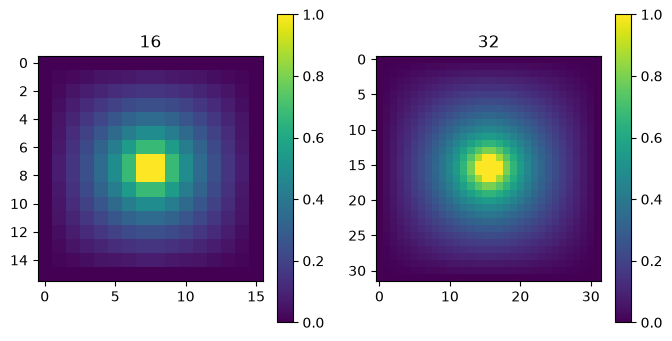

<Figure size 640x480 with 0 Axes>

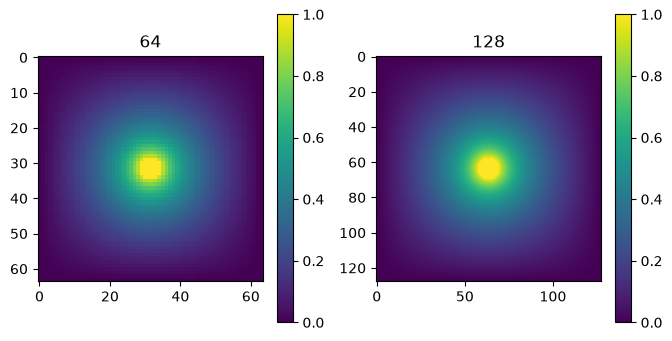

<Figure size 640x480 with 0 Axes>

<Figure size 800x400 with 0 Axes>

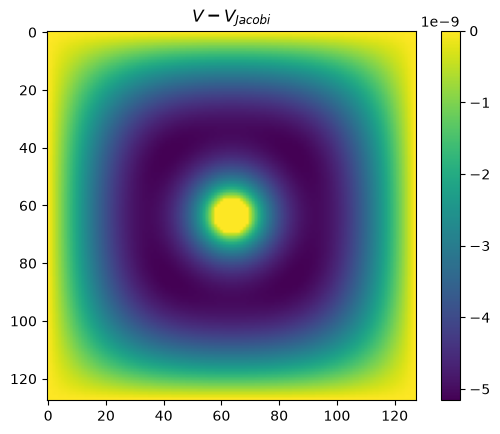

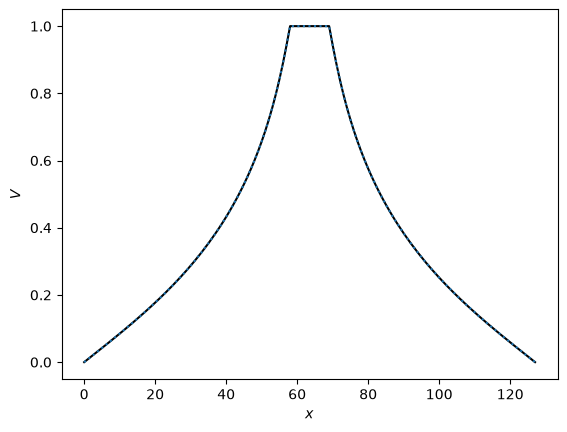

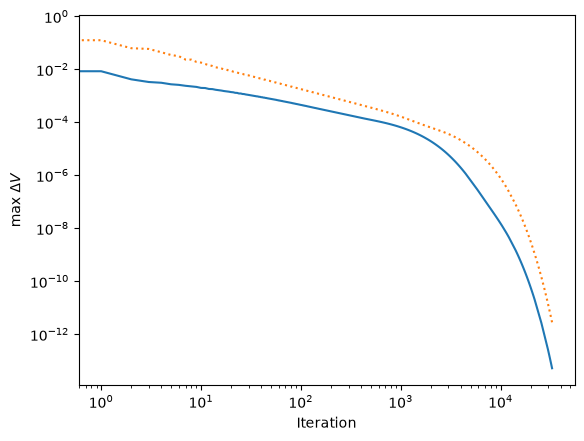

In [9]:
# Solve Laplace's equation with a multigrid method
n = 128
mask, bc = set_bcs(n)

# Initial guess for the potential
V0 = np.ones_like(bc) * 0.5

# First go down in resolution from fine to coarse
# and calculate the smoothed bc, mask and V arrays at each step
npass = 3
bcs = [bc,]
masks = [mask,]
Vs = [V0,]
for i in range(npass):
    bcs.append(deres(bcs[i]))
    masks.append(deres(masks[i]))
    Vs.append(deres(Vs[i]))

# Now step back up, relaxing at each stage    
for i in range(npass,0,-1):
    n0 = bcs[i].shape[0]
    Vs[i], deltaV = laplace(masks[i], bcs[i], 100, Vs[i], make_plot=False)
    print('n = %d, Delta V = %lg' % (n0, deltaV[-1],))
    Vs[i-1] = upres(Vs[i])

# Run the final grid for 2*n*n interations so that we can see how it converges
# now that the solution has been preconditioned
n0 = bcs[0].shape[0]
nn = 2*n0*n0
Vs[0], deltaV = laplace(masks[0], bcs[0], nn, Vs[0], make_plot=False)
print('n = %d, Delta V = %lg' % (n0, deltaV[-1],))

titles = ["%d" % (V.shape[0],) for V in Vs]
plot_matrices(Vs[::-1], nmax = 2, titles=titles[::-1])

plt.clf()
plt.title(r'$V-V_{Jacobi}$')
plt.imshow(Vs[0]-V_jacobi)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(n), Vs[0][int(n/2),:], 'k')
plt.plot(np.arange(n), V_jacobi[int(n/2),:], ':')
plt.ylabel(r'$V$')
plt.xlabel(r'$x$')
plt.show()

plt.clf()
plt.plot(np.arange(len(deltaV)), deltaV)
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi, ':')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.show()

The last plot shows that this method (blue curve in the final plot) converges more quickly than the Jacobi method on a single grid (orange dotted line). In particular, we can now get a much more reasonable low-accuracy solution in the first part of the curve (number of iterations << n^2). Whereas previously these solutions were completely wrong because the diffusion from the boundaries had travelled only a small distance, now the coarse grids have taken care of the global diffusion and so the overall solution is much more accurate.

The general idea of using some approximate scheme to improve the initial guess for a relaxation method is known as **preconditioning**, and is used in many codes. Here, we can think of the sequence of low resolution grids as a preconditioner for the final relaxation at full resolution.